# Huấn luyện Custom Dueling Double DQN (Scratch) trên Atari Pong

Sổ tay này hướng dẫn huấn luyện mô hình **Dueling Double DQN (Dueling DDQN)** tự phát triển bằng PyTorch trên môi trường Pong.

## Giới thiệu thuật toán và kiến trúc mô hình

### 1. Thuật toán Dueling Double DQN
Dueling DDQN là sự tích hợp của hai cải tiến mạnh mẽ vượt trội so với DQN truyền thống:
- **Double DQN**: Loại bỏ hiện tượng "đánh giá quá cao" (Overestimation bias) các giá trị hành động Q. Việc chọn hành động tốt nhất được quyết định bởi Online Network, còn việc lượng giá hành động đó được tính toán bởi Target Network.
- **Dueling Architecture**: Tách biệt luồng biểu diễn đặc trưng ở các lớp fully connected cuối thành hai dòng ước lượng độc lập:
  - **State-value $V(s)$**: Lượng giá mức độ tốt của việc đang đứng ở trạng thái $s$.
  - **Advantage $A(s, a)$**: Lượng giá mức độ vượt trội của từng hành động $a$ cụ thể so với mức trung bình tại trạng thái $s$.
  - Công thức kết hợp: $Q(s, a) = V(s) + \left( A(s, a) - \frac{1}{|\mathcal{A}|} \sum_{a'} A(s, a') \right)$

### 2. Kiến trúc mô hình mạng tích chập (Dueling CNN)
- Tương tự DQN, mô hình dùng CNN 3 lớp từ Nature DQN để xử lý các frame ảnh.
- Đầu ra của CNN phẳng được truyền song song vào hai nhánh Fully Connected riêng biệt:
  - Nhánh Giá trị $V(s)$: `Linear(feature_size, 512)` $\rightarrow$ `Linear(512, 1)`
  - Nhánh Lợi thế $A(s, a)$: `Linear(feature_size, 512)` $\rightarrow$ `Linear(512, num_actions)`

## Cấu hình môi trường và Import các thư viện

Để chạy notebook này độc lập trong thư mục con `notebooks/`, chúng ta cần thêm thư mục gốc của dự án vào đường dẫn tìm kiếm `sys.path` để import chính xác các module từ `src/`.

In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Thêm thư mục gốc vào đường dẫn hệ thống để import src
sys.path.append(os.path.abspath(os.path.join('..')))

from src.common.wrappers import make_atari_env
from src.common.utils import CSVLogger, save_checkpoint
from src.scratch.agent import DQNAgent

## Kiểm tra tăng tốc phần cứng (GPU CUDA)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Thiết bị huấn luyện: {device}")
if torch.cuda.is_available():
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")

Thiết bị huấn luyện: cuda
Tên GPU: NVIDIA GeForce RTX 5060 Ti


## Định nghĩa Siêu tham số (Hyperparameters)

Cấu hình các siêu tham số huấn luyện trực tiếp ngay trong notebook:

In [3]:
env_id = "PongNoFrameskip-v4"
total_steps = 500000       # Tổng số bước môi trường huấn luyện
lr = 1e-4                  # Tốc độ học của optimizer Adam
buffer_size = 30000       # Dung lượng tối đa của Replay Buffer
batch_size = 32            # Kích thước tập mẫu huấn luyện
target_update_freq = 2000 # Chu kỳ cập nhật trọng số cho Target Network
learning_starts = 5000    # Số bước thu thập dữ liệu khởi tạo trước khi bắt đầu cập nhật mạng
train_freq = 4             # Tần suất tối ưu hóa mạng (sau mỗi 4 bước môi trường)
seed = 42                  # Random seed để tái hiện kết quả

# Thư mục lưu kết quả học tập và các file mô hình
save_dir = "../data/models"
log_dir = "../data/logs"

os.makedirs(save_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

## Khởi tạo Môi trường Pong với Wrappers thống nhất

In [4]:
env = make_atari_env(env_id)
env.action_space.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

print(f"Trạng thái đầu vào: {env.observation_space.shape}")
print(f"Số lượng hành động: {env.action_space.n}")

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Trạng thái đầu vào: (4, 84, 84)
Số lượng hành động: 6


## Khởi tạo Tác nhân (Dueling DDQN Agent)

Sử dụng `DQNAgent` nhưng cấu hình `dueling=True` và `double=True` để kích hoạt mạng Dueling và tối ưu kiểu Double DQN.

In [5]:
agent = DQNAgent(
    state_shape=env.observation_space.shape,
    num_actions=env.action_space.n,
    learning_rate=lr,
    gamma=0.99,
    buffer_size=buffer_size,
    batch_size=batch_size,
    target_update_freq=target_update_freq,
    device=device,
    dueling=True,  # Kích hoạt Dueling DQN
    double=True   # Kích hoạt Double DQN updates
)

## Vòng lặp Huấn luyện (Training Loop)

Vòng lặp chạy huấn luyện hoàn chỉnh, ghi log định kỳ vào file CSV và tự động lưu checkpoint mô hình cứ sau mỗi 100,000 steps.

In [6]:
run_name = f"dueling_ddqn_scratch_seed{seed}_{int(time.time())}"
csv_file = os.path.join(log_dir, f"{run_name}.csv")
csv_logger = CSVLogger(
    filepath=csv_file,
    headers=["step", "episode", "reward", "epsilon", "loss", "duration"]
)

state, _ = env.reset(seed=seed)
episode_reward = 0.0
episode_steps = 0
episode_count = 0
episode_start_time = time.time()
episode_losses = []
best_mean_reward = -float("inf")
recent_rewards = []

epsilon_start = 1.0
epsilon_end = 0.01
exploration_fraction = 0.1
epsilon_decay_steps = int(total_steps * exploration_fraction)

print(f"Bắt đầu huấn luyện Custom Dueling DDQN Scratch trên {env_id}...")

for step in range(1, total_steps + 1):
    # Suy giảm epsilon tuyến tính
    epsilon = max(
        epsilon_end,
        epsilon_start - (epsilon_start - epsilon_end) * (step / epsilon_decay_steps)
    )
    
    # Chọn hành động
    action = agent.select_action(state, epsilon)
    
    # Bước đi trong môi trường
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    
    # Lưu vào buffer
    agent.replay_buffer.add(state, action, reward, next_state, done)
    
    state = next_state
    episode_reward += reward
    episode_steps += 1
    
    # Cập nhật trọng số
    if step > learning_starts and step % train_freq == 0:
        loss_val = agent.update()
        episode_losses.append(loss_val)
        
    # Đồng bộ Target Network
    if step % target_update_freq == 0:
        agent.update_target_network()
        print(f"Bước {step}/{total_steps} | Đồng bộ trọng số Target Network.")
        
    # Kết thúc tập phim
    if done:
        episode_duration = time.time() - episode_start_time
        episode_count += 1
        avg_loss = np.mean(episode_losses) if len(episode_losses) > 0 else 0.0
        
        # Log số liệu
        csv_logger.log({
            "step": step,
            "episode": episode_count,
            "reward": episode_reward,
            "epsilon": epsilon,
            "loss": avg_loss,
            "duration": episode_duration
        })
        
        if episode_count % 10 == 0 or episode_reward > -10:
            print(
                f"Tập {episode_count:4d} | Bước {step:6d} | "
                f"Phần thưởng: {episode_reward:5.1f} | Epsilon: {epsilon:.3f} | "
                f"Loss Trung Bình: {avg_loss:.5f} | Thời gian: {episode_duration:.1f}s"
            )
            
        # Lưu mô hình tốt nhất
        if episode_reward > best_mean_reward and step > learning_starts:
            best_mean_reward = episode_reward
            save_checkpoint(
                state={
                    "step": step,
                    "episode": episode_count,
                    "online_net_state_dict": agent.online_net.state_dict(),
                    "reward": episode_reward
                },
                filepath=os.path.join(save_dir, "dueling_ddqn_scratch_best.pt")
            )
            
        # Kiểm tra dừng sớm (Early Stopping)
        recent_rewards.append(episode_reward)
        if len(recent_rewards) > 10:
            recent_rewards.pop(0)
        if len(recent_rewards) >= 10 and np.mean(recent_rewards) >= 18.0:
            print(f"Dừng sớm (Early Stopping) tại bước {step}! Điểm trung bình 10 tập gần nhất: {np.mean(recent_rewards):.1f} >= 18.0. Tác nhân đã giải quyết thành công game Pong!")
            break
            
        # Reset
        state, _ = env.reset()
        episode_reward = 0.0
        episode_steps = 0
        episode_start_time = time.time()
        episode_losses = []
        
    # Lưu checkpoint định kỳ mỗi 100,000 steps
    if step % 100000 == 0:
        save_checkpoint(
            state={
                "step": step,
                "episode": episode_count,
                "online_net_state_dict": agent.online_net.state_dict(),
                "reward": episode_reward
            },
            filepath=os.path.join(save_dir, f"dueling_ddqn_scratch_step_{step}.pt")
        )

env.close()
print("Quá trình huấn luyện kết thúc thành công!")

Bắt đầu huấn luyện Custom Dueling DDQN Scratch trên PongNoFrameskip-v4...
Bước 2000/500000 | Đồng bộ trọng số Target Network.
Bước 4000/500000 | Đồng bộ trọng số Target Network.
Bước 6000/500000 | Đồng bộ trọng số Target Network.
Bước 8000/500000 | Đồng bộ trọng số Target Network.
Tập   10 | Bước   9099 | Phần thưởng: -21.0 | Epsilon: 0.820 | Loss Trung Bình: 0.02416 | Thời gian: 2.4s
Bước 10000/500000 | Đồng bộ trọng số Target Network.
Bước 12000/500000 | Đồng bộ trọng số Target Network.
Bước 14000/500000 | Đồng bộ trọng số Target Network.
Bước 16000/500000 | Đồng bộ trọng số Target Network.
Bước 18000/500000 | Đồng bộ trọng số Target Network.
Tập   20 | Bước  18065 | Phần thưởng: -20.0 | Epsilon: 0.642 | Loss Trung Bình: 0.01632 | Thời gian: 2.4s
Bước 20000/500000 | Đồng bộ trọng số Target Network.
Bước 22000/500000 | Đồng bộ trọng số Target Network.
Bước 24000/500000 | Đồng bộ trọng số Target Network.
Bước 26000/500000 | Đồng bộ trọng số Target Network.
Tập   30 | Bước  27056 | Phần

## Vẽ đồ thị kết quả huấn luyện

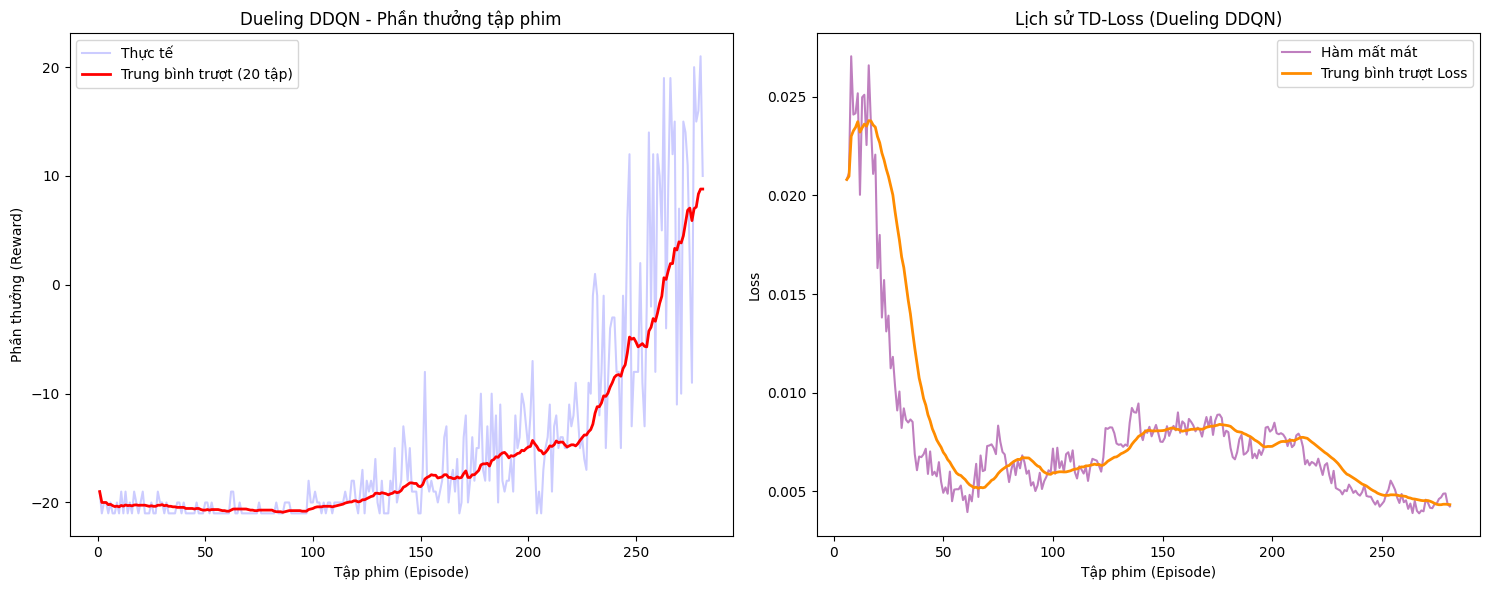

In [7]:
try:
    df = pd.read_csv(csv_file)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Đồ thị phần thưởng
    ax1.plot(df["episode"], df["reward"], alpha=0.2, color="blue", label="Thực tế")
    rolling_rew = df["reward"].rolling(window=20, min_periods=1).mean()
    ax1.plot(df["episode"], rolling_rew, color="red", linewidth=2, label="Trung bình trượt (20 tập)")
    ax1.set_title("Dueling DDQN - Phần thưởng tập phim")
    ax1.set_xlabel("Tập phim (Episode)")
    ax1.set_ylabel("Phần thưởng (Reward)")
    ax1.legend()
    
    # Đồ thị TD loss
    valid_loss_df = df[df["loss"] > 0]
    ax2.plot(valid_loss_df["episode"], valid_loss_df["loss"], color="purple", alpha=0.5, label="Hàm mất mát")
    rolling_loss = valid_loss_df["loss"].rolling(window=20, min_periods=1).mean()
    ax2.plot(valid_loss_df["episode"], rolling_loss, color="darkorange", linewidth=2, label="Trung bình trượt Loss")
    ax2.set_title("Lịch sử TD-Loss (Dueling DDQN)")
    ax2.set_xlabel("Tập phim (Episode)")
    ax2.set_ylabel("Loss")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Không thể vẽ đồ thị: {e}")